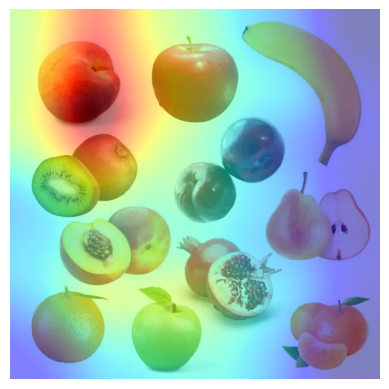

In [22]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

model = models.resnet18(pretrained=True)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
image = Image.open("img7_r1.png").convert("RGB")
input_tensor = transform(image).unsqueeze(0)

final_conv = model.layer4[1].conv2

activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output.detach())

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0].detach())

final_conv.register_forward_hook(forward_hook)
final_conv.register_backward_hook(backward_hook)

output = model(input_tensor)
pred_class = output.argmax(dim=1).item()
output[:, pred_class].backward()

act = activations[0].squeeze(0)
grad = gradients[0].squeeze(0)

weights = torch.mean(grad, dim=(1, 2))

cam = torch.zeros(act.shape[1:], dtype=torch.float32)
for i, w in enumerate(weights):
    cam += w * act[i, :, :]

cam = torch.relu(cam)

cam = cam - cam.min()
cam = cam / cam.max()

cam = cam.numpy()
cam = np.uint8(255 * cam)
cam = Image.fromarray(cam).resize((image.width, image.height), Image.LANCZOS)

plt.imshow(image)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.axis('off')
plt.show()

